<a href="https://colab.research.google.com/github/yashdeepspodder23/BlackHoleSimulations/blob/main/BHSim5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_5044/961641639.py:129: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  horizon_sphere = plt.Circle(bh_pos, Rh, color='#050505', edgecolor='cyan', lw=2, zorder=2, label=f'Kerr Horizon ($R_h$, a={a/M}M)')


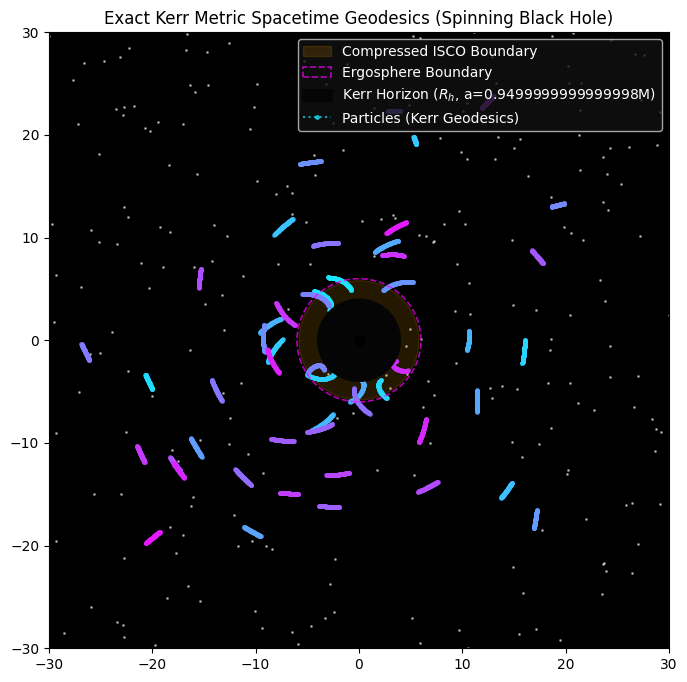

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import collections

# =====================================================================
# CONSTANTS & KERR SPIN PARAMETERS (Geometrized Units)
# =====================================================================
G = 1        # Gravitational constant
M = 3.0      # Mass of the black hole
dt = 0.075    # Time step (proper time increment d_tau)
num_p = 50   # Number of particles

# Kerr Spin Parameters
a = 0.95 * M  # Spin parameter (Max spin is a = M)

# Boundaries in the Kerr equatorial plane
Rh = M + np.sqrt(M**2 - a**2)       # Inner Event Horizon = ~2.31
R_ergo = 2 * M                      # Outer Ergosphere Boundary at equator = 4.0

# Calculate Kerr ISCO radius via exact GR formulas
Z1 = 1 + (1 - (a/M)**2)**(1/3) * ((1 + a/M)**(1/3) + (1 - a/M)**(1/3))
Z2 = np.sqrt(3 * (a/M)**2 + Z1**2)
R_isco = M * (3 + Z2 - np.sqrt((3 - Z1) * (3 + Z1 + 2 * Z2))) # ISCO shifts way inward!

# Initialize particle positions and velocities in Polar space
np.random.seed(105)
poss_polar = np.zeros((num_p, 4)) # [r, phi, vr, vphi]
poss_polar[:, 0] = np.random.uniform(6.0, 25.0, num_p)   # Radius 'r'
poss_polar[:, 1] = np.random.uniform(0, 2 * np.pi, num_p)  # Angle 'phi'
poss_polar[:, 2] = np.random.uniform(-0.05, 0.05, num_p)   # Radial velocity 'vr'

# Initialize angular velocities
for i in range(num_p):
    r_init = poss_polar[i, 0]
    # Mix of prograde (orbiting with spin) and retrograde (orbiting against spin) particles
    direction = 1 if np.random.rand() > 0.2 else -1
    poss_polar[i, 3] = direction * np.sqrt(G * M / r_init**3) * np.random.uniform(0.7, 1.2)

# Coordinate conversion maps for your Cartesian setup
poss = np.zeros((num_p, 2))
for i in range(num_p):
    poss[i, 0] = poss_polar[i, 0] * np.cos(poss_polar[i, 1])
    poss[i, 1] = poss_polar[i, 0] * np.sin(poss_polar[i, 1])

# Black hole position
bh_pos = np.array([0, 0])

# Global variables for trail
trail_length = 60
trail_data = [collections.deque(maxlen=trail_length) for _ in range(num_p)]

# =====================================================================
# KERR GEODESIC DERIVATIVES WITH FRAME DRAGGING
# =====================================================================
def kerr_geodesic_derivatives(state):
    r, phi, vr, vphi = state

    if r <= Rh:
        return np.array([0.0, 0.0, 0.0, 0.0])

    # Relativistic Conserved Quantities approximations per unit mass
    E = 1.0  # Specific energy at infinity
    L = (r**2) * vphi - (2 * M * a * E) / r  # Angular momentum adjusted for frame dragging

    # Radial Geodesic Acceleration equation for equatorial Kerr metric
    d_vr = -M/r**2 + (L**2 - a**2*(E**2 - 1))/r**3 + M*(L - a*E)**2/r**4 - 3*M*(L - a*E)**2/r**5

    # Angular velocity equation showing clear frame dragging coupling:
    # Notice that even if L=0, d_phi/d_tau remains positive due to the spin 'a'
    d_phi = L / r**2 + (2 * M * a * E) / r**3

    d_r = vr
    # Conserved angular momentum derivative step
    d_vphi = -(2.0 * vr * d_phi) / r + (6 * M * vr * a * E) / r**4

    return np.array([d_r, d_phi, d_vr, d_vphi])

# Update particle states using standard RK4 Integrator
def update_particles_kerr(poss_polar, poss):
    for i in range(len(poss_polar)):
        r = poss_polar[i, 0]

        if r <= Rh:
            # Swallowed inside Kerr horizon
            poss_polar[i, :] = np.array([0.0, 0.0, 0.0, 0.0])
            poss[i] = np.array([0.0, 0.0])
            continue

        # Runge-Kutta 4th Order numerical integration
        y = poss_polar[i]
        k1 = kerr_geodesic_derivatives(y)
        k2 = kerr_geodesic_derivatives(y + 0.5 * dt * k1)
        k3 = kerr_geodesic_derivatives(y + 0.5 * dt * k2)
        k4 = kerr_geodesic_derivatives(y + dt * k3)

        poss_polar[i] += (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

        # Translate back to Cartesian grid
        new_r, new_phi = poss_polar[i, 0], poss_polar[i, 1]
        poss[i, 0] = new_r * np.cos(new_phi)
        poss[i, 1] = new_r * np.sin(new_phi)

    return poss_polar, poss

# =====================================================================
# MATPLOTLIB RENDERING & LAYERING SETUP
# =====================================================================
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-30, 30)
ax.set_ylim(-30, 30)
ax.set_facecolor('black')

# Static background stars
num_stars = 250
star_x = np.random.uniform(-30, 30, num_stars)
star_y = np.random.uniform(-30, 30, num_stars)
ax.scatter(star_x, star_y, s=1, color='white', alpha=0.5, zorder=0)

# Accretion Disk matching the compressed Kerr ISCO
accretion_disk = plt.Circle(bh_pos, R_isco, color='orange', alpha=0.15, zorder=1, label='Compressed ISCO Boundary')
ax.add_patch(accretion_disk)

# Outer Ergosphere Boundary Ring
ergo_zone = plt.Circle(bh_pos, R_ergo, color='magenta', fill=False, linestyle='--', lw=1.2, alpha=0.7, zorder=1.8, label='Ergosphere Boundary')
ax.add_patch(ergo_zone)

# True Spinning Event Horizon Core
horizon_sphere = plt.Circle(bh_pos, Rh, color='#050505', edgecolor='cyan', lw=2, zorder=2, label=f'Kerr Horizon ($R_h$, a={a/M}M)')
ax.add_patch(horizon_sphere)

bh = plt.scatter(*bh_pos, color='black', s=50, zorder=3)

# Build trail objects
particles_trails = []
colors = plt.cm.cool(np.linspace(0.1, 0.9, num_p)) # Highly energetic cyan/magenta contrast styling
for i in range(num_p):
    if i == 0:
        line, = ax.plot([], [], 'o:', color=colors[i], markersize=2.5, alpha=0.7, label='Particles (Kerr Geodesics)', zorder=1.5)
    else:
        line, = ax.plot([], [], 'o:', color=colors[i], markersize=2.5, alpha=0.7, zorder=1.5)
    particles_trails.append(line)

ax.legend(loc='upper right', facecolor='#111111', labelcolor='white')
plt.title('Exact Kerr Metric Spacetime Geodesics (Spinning Black Hole)', color='black')

# =====================================================================
# ANIMATION LOOP EXECUTOR
# =====================================================================
def init():
    for line in particles_trails:
        line.set_data([], [])
    return particles_trails

def animate(frame):
    global poss_polar, poss
    poss_polar, poss = update_particles_kerr(poss_polar, poss)

    for i in range(num_p):
        if not np.all(poss[i] == 0.0):
            trail_data[i].append(poss[i].copy())

    artists_to_return = []
    for i, line in enumerate(particles_trails):
        x_coords = [p[0] for p in trail_data[i]]
        y_coords = [p[1] for p in trail_data[i]]
        line.set_data(x_coords, y_coords)
        artists_to_return.append(line)

    return artists_to_return

ani = FuncAnimation(fig, animate, frames=600, init_func=init, interval=25, blit=True)
#plt.show()

from IPython.display import HTML
html_animation = HTML(ani.to_html5_video())
display(html_animation)